<a href="https://colab.research.google.com/github/fareehanezam/GNCIPL_Projects/blob/main/GNCIPL_Project4_Gene_Expression_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name
Gene Expression Clustering

# Project Summary

**Project Title:** Gene Expression Clustering  
**Domain:** Biotechnology  
**Data Type:** Gene × Patient Matrix  
**Preprocessing:** Normalized rows  
**Dimensionality Reduction:** PCA  
**Clustering Method:** Hierarchical  
**Evaluation Metric:** Cophenetic Correlation  
**Output:** Similar Gene Groups  
**Tools and Libraries:** Scikit-learn, Seaborn, SciPy, Plotly  

This notebook demonstrates gene clustering using a **small public dataset from GEO** (GSE15258).

#Github Link
https://github.com/fareehanezam/GNCIPL_Projects/blob/main/GNCIPL_Project4_Gene_Expression_Clustering.ipynb

## Problem Statement

The goal of this project is to identify groups of genes with similar expression patterns across different patient samples using a publicly available gene expression dataset (GSE15258). By applying dimensionality reduction techniques like PCA and hierarchical clustering, we aim to group similar gene.

## 1. Import Required Libraries

In [1]:
!pip install GEOparse
!pip install plotly

In [2]:
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
import plotly.express as px
import plotly.figure_factory as ff

sns.set(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (8,6)
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2. Download a Small GEO Dataset
We will use **GSE15258** which has ~30 samples. GEOparse helps us fetch the expression values.

In [3]:
gse = GEOparse.get_GEO(geo="GSE15258", destdir=".")
df = gse.pivot_samples("VALUE")
print("Shape (genes × samples):", df.shape)
df.head()

14-Sep-2025 07:59:38 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
14-Sep-2025 07:59:38 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15258/soft/GSE15258_family.soft.gz to ./GSE15258_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15258/soft/GSE15258_family.soft.gz to ./GSE15258_family.soft.gz
100%|██████████| 49.0M/49.0M [00:01<00:00, 32.8MB/s]
14-Sep-2025 07:59:40 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
14-Sep-2025 07:59:40 DEBUG downloader - Moving /tmp/tmpvr4rmqn7 to /content/GSE15258_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpvr4rmqn7 to /content/GSE15258_family.soft.gz
14-Sep-2025 07:59:40 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15258/soft/GSE15258_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE1525

Shape (genes × samples): (54675, 86)


name,GSM381194,GSM381195,GSM381196,GSM381197,GSM381198,GSM381199,GSM381200,GSM381201,GSM381202,GSM381203,...,GSM381270,GSM381271,GSM381272,GSM381273,GSM381274,GSM381275,GSM381276,GSM381277,GSM381278,GSM381279
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,2.377898,2.378662,2.382631,2.378621,2.461926,3.290609,2.536218,2.377062,2.456681,2.721739,...,2.380056,2.615649,2.377875,2.376057,2.702890,2.381181,2.474380,2.389282,2.375837,2.438526
1053_at,7.109049,5.156438,5.321988,5.195298,5.980662,6.352822,5.314602,5.440205,5.148019,5.460967,...,5.693693,5.226776,5.352625,5.136478,6.135809,6.828485,5.215068,5.171455,5.582465,6.478445
117_at,9.630326,8.871972,8.348816,9.557484,8.807910,9.133817,8.716893,8.810138,8.196032,9.051512,...,9.045299,8.207536,8.773177,8.635889,8.638233,8.829302,8.988185,8.082524,8.350547,9.403558
121_at,2.331110,2.337406,2.334704,2.643543,2.334267,2.337572,2.342447,2.339926,2.338847,2.338775,...,2.339649,2.418437,2.349566,2.356812,2.343669,2.344477,2.332166,2.337505,2.329407,2.347640
1255_g_at,2.326892,2.325880,2.326533,2.330819,2.327032,2.328993,2.328094,2.329099,2.330408,2.328855,...,2.331796,2.326758,2.330238,2.327100,2.331183,2.330042,2.324799,2.325841,2.325235,2.329681


✅ Each row is a **gene** and each column is a **patient sample**.

## 3. Preprocessing: Normalize and Filter Genes
- Normalize rows → so each gene has mean = 0 and variance = 1.
- Filter top **500 most variable genes** (reduces noise).

In [4]:
df.index = df.index.map(str)
df.columns = df.columns.map(str)
df = df.apply(lambda r: r.fillna(r.mean()), axis=1)

# Row-wise normalization
df_norm = df.subtract(df.mean(axis=1), axis=0)
df_norm = df_norm.divide(df.std(axis=1).replace(0,1), axis=0)

# Keep top 500 variable genes (or less if dataset smaller)
top_n = min(500, df_norm.shape[0])
top_genes = df_norm.var(axis=1).sort_values(ascending=False).head(top_n).index
df_filt = df_norm.loc[top_genes]
print("After filtering, shape:", df_filt.shape)

After filtering, shape: (500, 86)


✅ We kept only the most variable genes to focus on important expression patterns.

## 4. PCA: Visualize Genes in 2D and 3D

Explained variance ratio (3 PCs): [0.07468204 0.06006732 0.04718143]


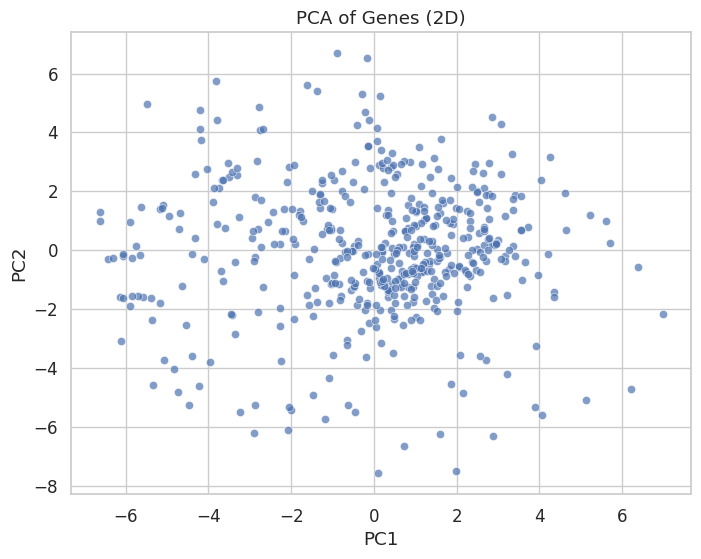

In [5]:
X = df_filt.values
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)
print("Explained variance ratio (3 PCs):", pca.explained_variance_ratio_)

# 2D PCA Scatter (Seaborn)
pca_df = pd.DataFrame(X_pca[:, :2], index=df_filt.index, columns=["PC1","PC2"])
sns.scatterplot(x="PC1", y="PC2", data=pca_df, s=35, alpha=0.7)
plt.title("PCA of Genes (2D)")
plt.show()

# 2D Interactive PCA Scatter (Plotly)
fig2d = px.scatter(x=X_pca[:,0], y=X_pca[:,1], hover_name=df_filt.index,
                  title="Interactive PCA (2D)", labels={'x':'PC1','y':'PC2'})
fig2d.show()

# 3D Interactive PCA Scatter (Plotly)
fig3d = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2], hover_name=df_filt.index,
                     title="Interactive PCA (3D)", labels={'x':'PC1','y':'PC2','z':'PC3'})
fig3d.show()

✅ Genes close together in PCA plots have **similar expression profiles**.

## 5. Hierarchical Clustering (Genes)

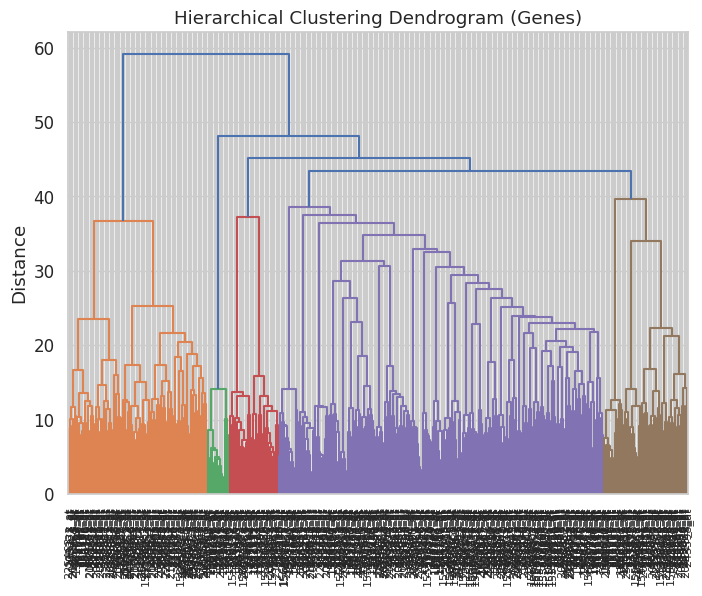

In [6]:
distances = pdist(X, metric="euclidean")
Z = linkage(distances, method="ward")

# Static dendrogram (Matplotlib)
dendrogram(Z, labels=df_filt.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram (Genes)")
plt.ylabel("Distance")
plt.show()

# Interactive dendrogram (Plotly)
fig_d = ff.create_dendrogram(X, orientation='left', labels=df_filt.index.tolist(), linkagefun=lambda x: linkage(x, 'ward'))
fig_d.update_layout(width=800, height=1000)
fig_d.show()

✅ The dendrogram shows how genes group step by step. You can zoom in with Plotly.

## 6. Cophenetic Correlation Evaluation

In [9]:
coph_dists, coph_link = cophenet(Z, distances)
from scipy.stats import pearsonr
corr, _ = pearsonr(distances, coph_link)
print("Cophenetic correlation coefficient:", round(corr, 4))

Cophenetic correlation coefficient: 0.3652


✅ A value closer to **1** means the clustering tree represents gene similarities well.

## 7. Extract Similar Gene Groups

In [10]:
K = 3
gene_labels = fcluster(Z, t=K, criterion="maxclust")
cluster_series = pd.Series(gene_labels, index=df_filt.index, name="Cluster")
print(cluster_series.value_counts().sort_index())

Cluster
1    112
2     18
3    370
Name: count, dtype: int64


✅ Shows the number of genes in each group.

In [11]:
for c in sorted(cluster_series.unique()):
    print("\nCluster", c, "genes:")
    print(cluster_series[cluster_series == c].index.tolist()[:10])


Cluster 1 genes:
['234023_s_at', '242576_x_at', '204306_s_at', '1554715_at', '1559911_at', '203333_at', '216519_s_at', '243007_at', '202259_s_at', '227103_s_at']

Cluster 2 genes:
['215334_at', '238048_at', '229502_at', '1566728_at', '233916_at', '235079_at', '1563540_at', '233298_at', '210171_s_at', '233460_at']

Cluster 3 genes:
['216980_s_at', '1556518_at', '1562710_at', '222247_at', '237935_at', '237493_at', '208031_s_at', '218934_s_at', '236219_at', '1557177_at']


✅ Example gene names from each cluster.

## 8. Heatmap of Clusters (Static)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



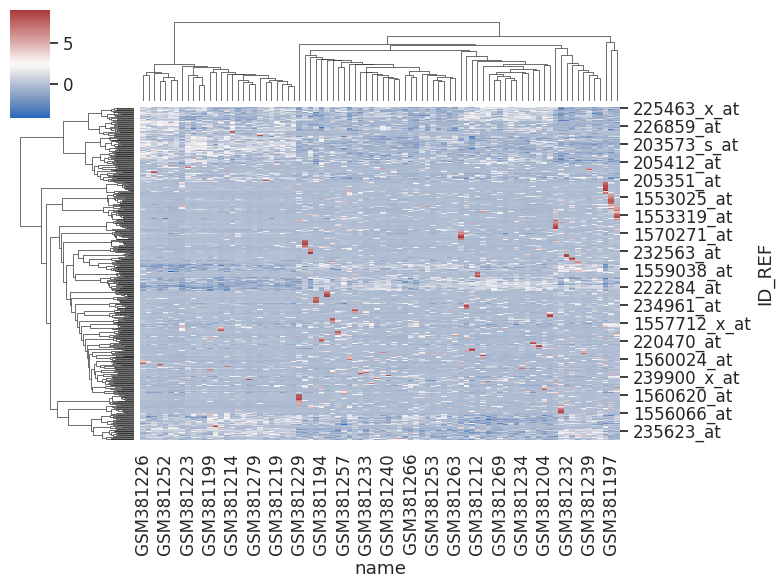

In [12]:
sns.clustermap(df_filt, method="ward", cmap="vlag", figsize=(8,6))
plt.show()

✅ Heatmap groups both genes and patients by similarity.

## 9. Save Cluster Assignments

In [13]:
cluster_series.to_csv("gene_clusters.csv")
print("✅ Gene clusters saved to gene_clusters.csv")

✅ Gene clusters saved to gene_clusters.csv


## 10. Conclusion
- **PCA** (2D & 3D) helped visualize gene similarities.
- **Hierarchical clustering** grouped genes based on expression.
- **Cophenetic correlation** measured clustering quality.
- **Seaborn** gave static, simple visuals; **Plotly** allowed interactive exploration.
- Gene groups may represent biologically related functions.

👉 This is how biologists explore gene expression patterns to discover new insights.